# PageRank Algorithm – Final Project
### Mathematical Modeling, Analysis and Python Implementation

Author: Stefan Popov<br>
Course: Mathematics for Developers<br>
Final Project

## Problem Statement

The goal of this project is to study and implement the PageRank algorithm,
which is used to rank nodes in a network. The algorithm evaluates the
importance of pages based on the structure of incoming links.

In this project we explore the mathematical model behind PageRank,
implement the algorithm in Python and analyze its convergence behavior.

## 1. Introduction

Search engines must determine which pages on the internet are the most important. Since the web contains billions of pages, ranking them efficiently is a major challenge.

The PageRank algorithm is a mathematical method that ranks web pages based on their link structure. The central idea is:

**A page is important if other important pages link to it.**

In this project we will:

- Model the web as a directed graph
- Explain the mathematical formula behind PageRank
- Implement the algorithm in Python
- Perform experiments on different network structures
- Analyze convergence and algorithm behavior


## 2. Modeling the Web as a Graph

The internet can be represented as a **directed graph**.

- Nodes represent web pages
- Edges represent hyperlinks

This allows us to analyze the web using graph theory.


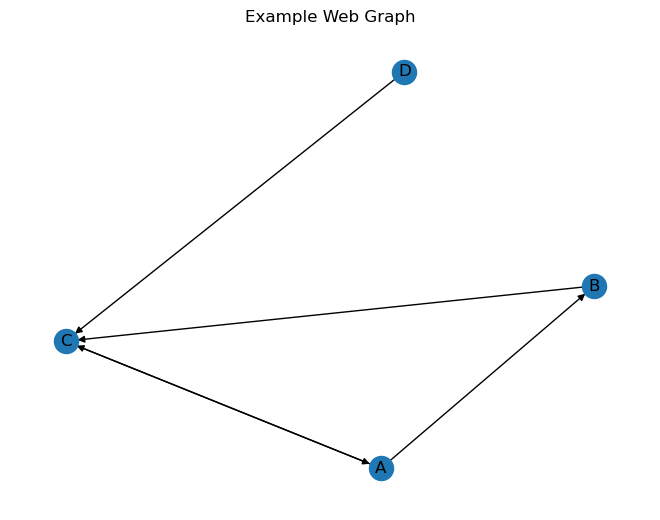

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

edges = [
('A','B'),
('A','C'),
('B','C'),
('C','A'),
('D','C')
]

G.add_edges_from(edges)

nx.draw(G, with_labels=True)
plt.title('Example Web Graph')
plt.show()


## 3. Mathematical Model

To compute PageRank we represent the link structure as a matrix.

The PageRank formula distributes importance between pages:

PR(A) = Σ PR(B) / L(B)

Where:

- B is a page linking to A
- L(B) is the number of outgoing links from page B

This means each page shares its importance equally among its outgoing links.


## 4. Random Surfer Model

In reality, users do not always follow links. Sometimes they jump to a random page.

This behavior is modeled using the **damping factor (d)**.

Typical value:

d = 0.85

The PageRank equation becomes:

PR = d * M * PR + (1-d) / N

Where:

- M is the transition probability matrix
- N is the number of pages


## 5. Building the Matrix Representation


In [2]:
import numpy as np

M = np.array([
[0,0,1,0],
[1,0,0,0],
[1,1,0,1],
[0,0,1,0]
], dtype=float)

column_sums = M.sum(axis=0)
M = M / column_sums

M


array([[0. , 0. , 0.5, 0. ],
       [0.5, 0. , 0. , 0. ],
       [0.5, 1. , 0. , 1. ],
       [0. , 0. , 0.5, 0. ]])

## 6. Implementing the PageRank Algorithm

We compute PageRank iteratively until the values stabilize.


In [3]:
d = 0.85
N = 4

rank = np.ones(N) / N

for i in range(100):
    rank = d * M @ rank + (1-d)/N

rank


array([0.21991382, 0.13096337, 0.42920899, 0.21991382])

## 7. Visualization of Page Importance

The following chart shows the PageRank score of each page.


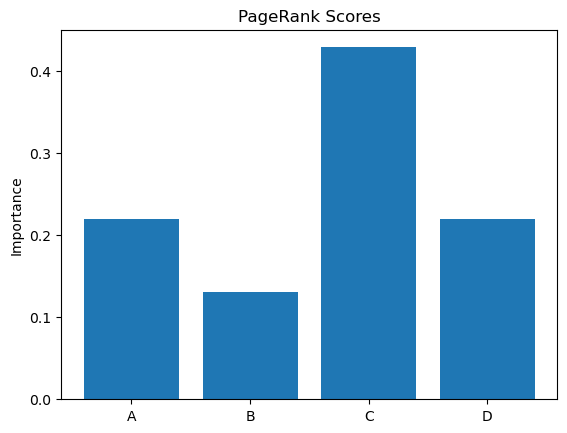

In [4]:
pages = ['A','B','C','D']

plt.bar(pages, rank)
plt.title('PageRank Scores')
plt.ylabel('Importance')
plt.show()


## 8. Convergence Analysis

The PageRank algorithm converges after several iterations.
We track how the rank of one page changes during iterations.


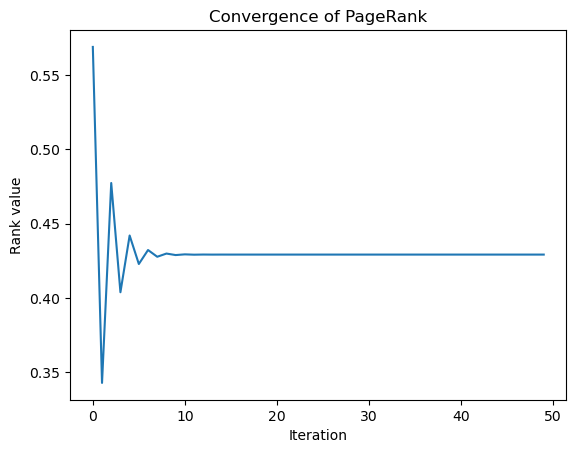

In [5]:
rank = np.ones(N) / N
history = []

for i in range(50):
    rank = d * M @ rank + (1-d)/N
    history.append(rank[2])

plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Rank value')
plt.title('Convergence of PageRank')
plt.show()


## 9. Random Graph Experiment

To test the algorithm in a larger environment we generate a random directed graph.


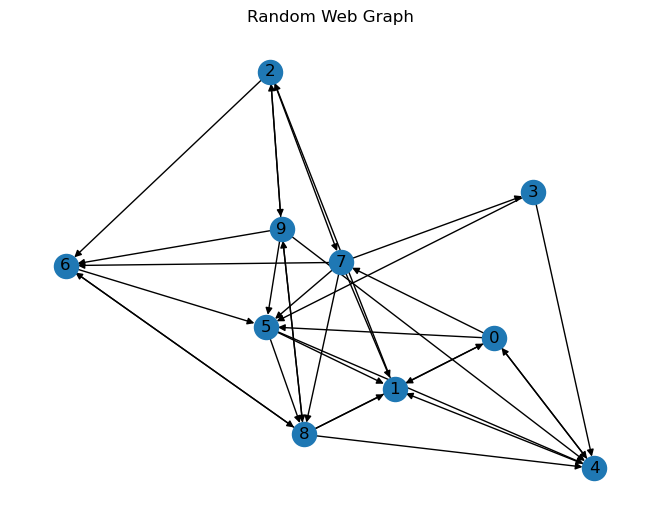

In [6]:
G_random = nx.gnp_random_graph(10, 0.3, directed=True)

nx.draw(G_random, with_labels=True)
plt.title('Random Web Graph')
plt.show()


In [7]:
pagerank_scores = nx.pagerank(G_random)
pagerank_scores


{0: 0.0814579400953597,
 1: 0.14380140681046316,
 2: 0.15041332981911135,
 3: 0.027737433688221465,
 4: 0.10949713162106428,
 5: 0.11398621598440982,
 6: 0.10345722510334396,
 7: 0.07492697888705081,
 8: 0.11718399723093711,
 9: 0.07753834076003838}

## 10. Complexity Analysis

The PageRank algorithm requires repeated matrix multiplications.

For:

N pages
k iterations

The computational complexity is approximately:

O(k * N^2)

Large search engines optimize this using sparse matrices and distributed computing.


## 11. Applications

The PageRank concept is used in many fields:

- Search engine ranking
- Scientific citation analysis
- Social network influence measurement
- Recommendation systems


## 12. Future Work

Future improvements of this project could include:

- applying PageRank to larger web graphs
- implementing optimized versions using sparse matrices
- comparing PageRank with other ranking algorithms
- analyzing how different damping factors affect convergence

## 13. Conclusion

In this project we studied the PageRank algorithm and implemented it in Python.

We demonstrated how graph theory, probability and linear algebra can be applied to rank nodes in a network.

The experiments showed that pages receiving links from important pages accumulate higher rank values.

This confirms the fundamental idea behind the PageRank algorithm: **importance flows through links in a network**.


## 14.References

Page, L., Brin, S., Motwani, R., Winograd, T. (1999).
The PageRank Citation Ranking: Bringing Order to the Web.

Langville, A., Meyer, C. (2006).
Google's PageRank and Beyond: The Science of Search Engine Rankings.